In [21]:
import numpy as np
import pandas as pd


In [22]:
from sklearn.model_selection import train_test_split,GridSearchCV, learning_curve, ShuffleSplit, cross_val_score

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 0

In [24]:
data_path = 'australian.dat'
credit = np.genfromtxt(data_path)
credit = pd.DataFrame(data = credit)
credit.columns=['X1','X2','X3','X4','X5','X6','X7','X8','X9','X10','X11','X12','X13','X14','Y']
print(credit.head())

    X1     X2     X3   X4   X5   X6     X7   X8   X9   X10  X11  X12    X13  \
0  1.0  22.08  11.46  2.0  4.0  4.0  1.585  0.0  0.0   0.0  1.0  2.0  100.0   
1  0.0  22.67   7.00  2.0  8.0  4.0  0.165  0.0  0.0   0.0  0.0  2.0  160.0   
2  0.0  29.58   1.75  1.0  4.0  4.0  1.250  0.0  0.0   0.0  1.0  2.0  280.0   
3  0.0  21.67  11.50  1.0  5.0  3.0  0.000  1.0  1.0  11.0  1.0  2.0    0.0   
4  1.0  20.17   8.17  2.0  6.0  4.0  1.960  1.0  1.0  14.0  0.0  2.0   60.0   

      X14    Y  
0  1213.0  0.0  
1     1.0  0.0  
2     1.0  0.0  
3     1.0  1.0  
4   159.0  1.0  


In [25]:
X = credit.iloc[:, :-1].values
y = credit.iloc[:, -1].values

encode_rule = ColumnTransformer(transformers=[('one_hot_encoder', OneHotEncoder(categories='auto'), [3,4,5,11])],remainder = 'passthrough')


In [26]:
X = encode_rule.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state= randstate)
print(X_train.shape, X_test.shape)

(552, 38) (138, 38)


Text(0.5, 1.0, 'DT validation curve for max_depth')

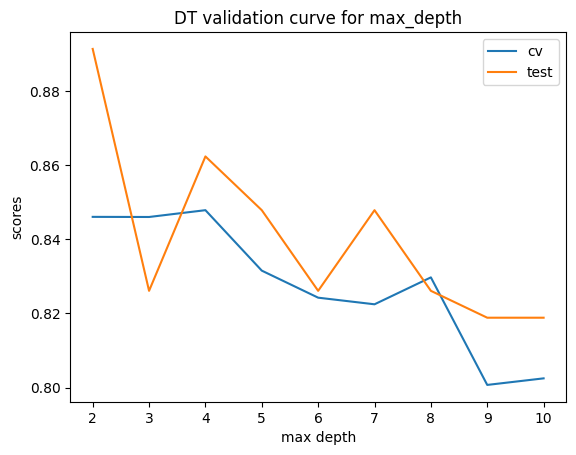

In [29]:
cv_accuracies_by_depth, test_accuracies_by_depth = [], []
max_depth_values = np.arange(2,11)

for curr_max_depth in max_depth_values:
    tree = DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)
    val_scores = cross_val_score(estimator=tree, X = X_train, y = y_train, cv = 5, scoring='accuracy')
    cv_accuracies_by_depth.append(val_scores.mean())
    tree.fit(X_train, y_train)
    curr_pred = tree.predict(X_test)
    test_accuracies_by_depth.append(accuracy_score(curr_pred, y_test))
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [34]:
parameter = {
    'max_depth': [2,3,4,5,6,7],
    'min_samples_split' : np.arange(2,202,20),
    'min_samples_leaf' : np.arange(1,201,20),
    'max_leaf_nodes': (2,5,10,20,50),
    'class_weight': ['balanced', None]
}
grid = GridSearchCV(DecisionTreeClassifier(), parameter, verbose=1, n_jobs=-1)
gridfit = grid.fit(X_train, y_train)
print(gridfit.best_params_)
y_pred = gridfit.predict(X_test)
print(accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 6000 candidates, totalling 30000 fits
{'class_weight': None, 'max_depth': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(2)}
0.8623188405797102


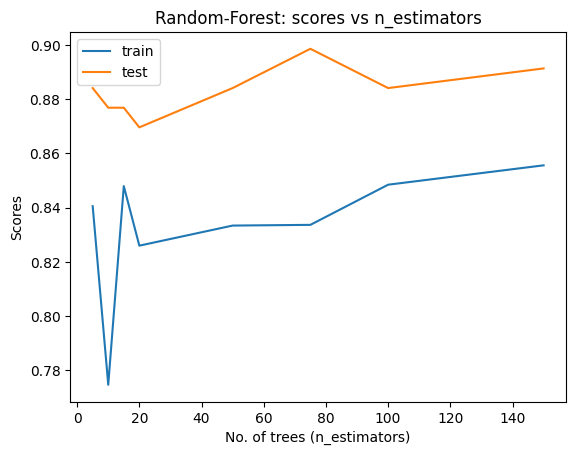

In [35]:
num_trees = [5,10,15,20,50,75,100,150]
train_acc = []
test_acc = []
for ntrees in num_trees:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=0, n_jobs=-1).fit(X_train, y_train)
    temp_train_acc = cross_val_score(rf, X_test, y_test, cv= 5, scoring='accuracy')
    train_acc.append(temp_train_acc.mean())
    test_acc.append(accuracy_score(rf.predict(X_test), y_test))
plt.plot(num_trees, train_acc, label='train')
plt.plot(num_trees, test_acc, label='test')
plt.legend()
plt.xlabel('No. of trees (n_estimators)')
plt.ylabel('Scores')
plt.title('Random-Forest: scores vs n_estimators');

In [36]:
parameter={
    'max_depth': [2,3,5,7,10, 20],
    'min_samples_leaf': [1,10,30,60],
    'max_features': [1.0,'log2','sqrt','auto'],
    'n_estimators': [1,2,3,5,10, 20, 50, 100,170]
    }
grid=GridSearchCV(RandomForestClassifier(random_state=random_state), parameter,n_jobs=-1, verbose=1)
gridfit=grid.fit(X_train,y_train)
print(gridfit.best_params_)
y_pred = gridfit.predict(X_test)
print(accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


c:\Users\hungn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1080 fits failed out of a total of 4320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
732 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hungn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hungn\miniconda3\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\hungn\miniconda3\Lib\site-packages\sklearn\base.py", line 492, in _validate_pa

{'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 100}
0.8840579710144928
